# Anomaly Detection

# AD - bu malumotlqar ichida odatiy bo`lmagan  (g`alati) nuqtalarni aniqlash jarayoni

# Real Misollar

- Fraud Transaction (nakdagi kartadagi  ogirlik)
- server xatolari 
- sensor buzilishi 
- tibbiy signallarda nomaly bo`lishi 
- network attack 

#  Fraud Transaction xolatini misollarda korish 

- 1 == 20 $ 
- 2 ==  23 $ 
- 3 ==  19 $ 
- 4 == 25 $ 
- 5 == 1000 $   ## Xolat Anomaly 

# Anomaly Detection Turlari 

- Point Anomaly 
bitta nuqta anomal bo`lgan xolat -- 10, 14, 15, 11, 140-anomaly
- Contextual Anomaly 
konteksga bog`liq anomal xolat - temperatura  = 30 C , yozda - normal // qishda - anomaly 
- Corrective Anomaly
 bir guruh anomaly holatlar , network attack paketlar

# Anomaly Detection Uchun Algaritmlar

- Isolation Forest -- eng mashxur

- One Class SVM  -- klassik usul 

- Local Outlier Factor - density asosida 

- Autoencoder -- DL 

- Elliptic Envelope -- Guassian model 

# Isolation Forest 

bu eng ko`p ishlatiladigan algaritm xisoblanadi, Idea: Anomaly datapoint tezroq ajratiladi , model random trees lar qurish orqali ishlaydi, normal datapoint - chuqur node, anomaly - tez ajratadi

In [2]:
!pip install scikit_learn pandas matplotlib seaborn 


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Data ni yaratib olish 

In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

np.random.seed(42)

normal_data = np.random.normal(0,1,(200,2))
anomaly = np.random.uniform(low=-6, high=6, size=(20,2)) 
 
data = np.vstack([normal_data, anomaly])


df = pd.DataFrame(data, columns=["x", "y"])

# Datani vizual ko`rish 

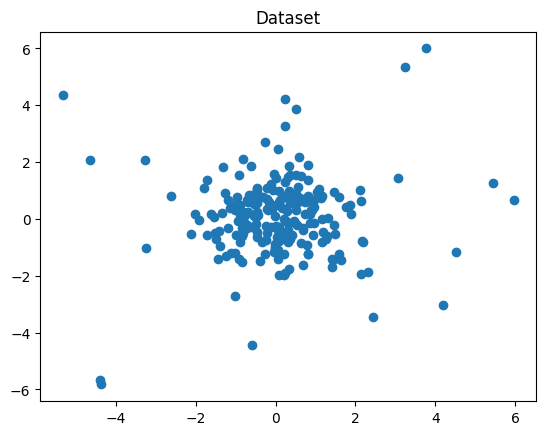

In [4]:
plt.scatter(df["x"], df["y"])
plt.title("Dataset")
plt.show()

# Isolation Forest

In [5]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=100,
    contamination=0.1,
    random_state=42
)

model.fit(df)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.1
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


# Prediction 

In [12]:
x = df.drop(columns=["Anomaly"], errors= "ignore")
df["Anomaly"] = model.predict(x)
print(df["Anomaly"])

0      1
1      1
2      1
3      1
4      1
      ..
215   -1
216   -1
217   -1
218   -1
219    1
Name: Anomaly, Length: 220, dtype: int64


In [14]:
df["Label"]  = df["Anomaly"].map({1: "Normal", -1: "Anomaly"})
print(df[["Anomaly", "Label"]])

     Anomaly    Label
0          1   Normal
1          1   Normal
2          1   Normal
3          1   Normal
4          1   Normal
..       ...      ...
215       -1  Anomaly
216       -1  Anomaly
217       -1  Anomaly
218       -1  Anomaly
219        1   Normal

[220 rows x 2 columns]


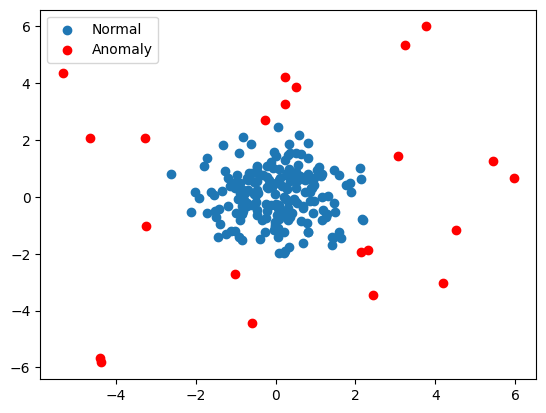

In [15]:
normal = df[df["Anomaly"] == 1]
anomaly = df[df["Anomaly"] == -1]

plt.scatter(normal["x"], normal["y"], label = "Normal")
plt.scatter(anomaly["x"], anomaly["y"], color="red", label = "Anomaly")

plt.legend()
plt.show()

# Local Outlier Factor (LOF) 

In [16]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.1
)

pred = lof.fit_predict(df[["x", "y"]])

df["lof_anomaly"] = pred 

# One Class SVM 

In [17]:
from sklearn.svm import OneClassSVM

svm = OneClassSVM(
    kernel="rbf",
    gamma=0.1,
    nu=0.05
)

svm.fit(df[["x", "y"]])

df["svm_anomaly"] = svm.predict(df[["x", "y"]])

# Real Dataset bilan Amaliyot 

In [18]:
import pandas as pd 
df = pd.read_csv(r"C:\Users\rrasu\Desktop\Project_For_Practise\Data\Raw_Data\creditcard.csv")

In [19]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [21]:
import pandas as pd 
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt 
import seaborn as sns 

In [23]:
x = df.drop("Class", axis=1) 
y = df["Class"]

In [27]:
scaler = StandardScaler()
x[["Time", "Amount"]] = scaler.fit_transform(x[["Time", "Amount"]])

In [29]:
x.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.996583,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964
1,-1.996583,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475
2,-1.996562,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686
3,-1.996562,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534
4,-1.996541,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403


In [30]:
iso_fortest = IsolationForest(
    n_estimators=100,
    max_samples="auto",
    contamination=0.1,
    random_state=42
)

iso_fortest.fit(x)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.1
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [31]:
y_pred = iso_fortest.predict(x)
y_pred = [1 if x == -1 else 0 for x in y_pred]

In [32]:
y_pred

[0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,


In [36]:
print("Confusion Matrix: ")
print(confusion_matrix(y, y_pred))


print("Confusion Report: ")
print(classification_report(y, y_pred, digits = 4))

Confusion Matrix: 
[[256268  28047]
 [    58    434]]
Confusion Report: 
              precision    recall  f1-score   support

           0     0.9998    0.9014    0.9480    284315
           1     0.0152    0.8821    0.0300       492

    accuracy                         0.9013    284807
   macro avg     0.5075    0.8917    0.4890    284807
weighted avg     0.9981    0.9013    0.9464    284807



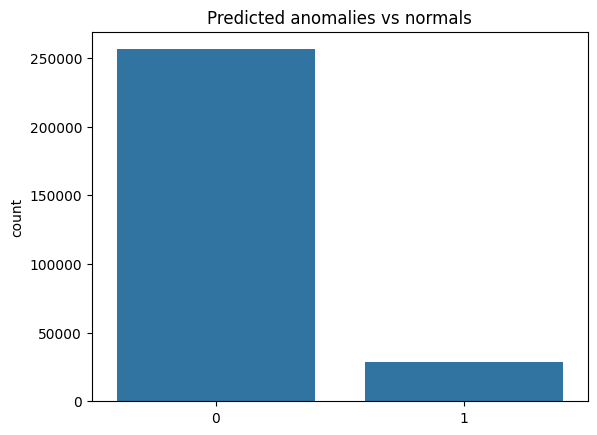

In [37]:
sns.countplot(x=y_pred)
plt.title("Predicted anomalies vs normals")
plt.show()

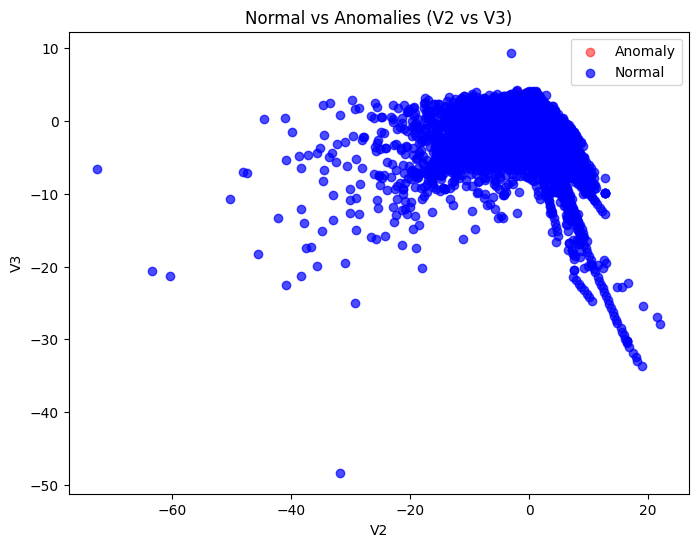

In [44]:
y_pred_series = pd.Series(y_pred, index=x.index)

plt.figure(figsize=(8, 6))

plt.scatter(x[y_pred_series == 0]['V2'],
            x[y_pred_series == 0]['V3'],
            c='red', label='Anomaly', alpha=0.5)


plt.scatter(x[y_pred_series == 1]['V2'],
            x[y_pred_series == 1]['V3'],
            c='blue', label='Normal', alpha=0.7)

plt.title("Normal vs Anomalies (V2 vs V3)")
plt.xlabel("V2")
plt.ylabel("V3")
plt.legend()
plt.show()


In [45]:
df["anomaly"] = y_pred_series

anomalies = df[df["anomaly"] == 1]

print("Number of Detected anomalies:", anomalies.shape[0])
print(anomalies.head())

Number of Detected anomalies: 28481
    Time        V1        V2        V3        V4        V5        V6  \
2    1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499   
7    7.0 -0.644269  1.417964  1.074380 -0.492199  0.948934  0.428118   
14  12.0 -2.791855 -0.327771  1.641750  1.767473 -0.136588  0.807596   
18  14.0 -5.401258 -5.450148  1.186305  1.736239  3.049106 -1.763406   
51  36.0 -1.004929 -0.985978 -0.038039  3.710061 -6.631951  5.122103   

          V7        V8        V9  ...       V22       V23       V24       V25  \
2   0.791461  0.247676 -1.514654  ...  0.771679  0.909412 -0.689281 -0.327642   
7   1.120631 -3.807864  0.615375  ... -1.015455  0.057504 -0.649709 -0.415267   
14 -0.422911 -1.907107  0.755713  ...  0.222182  1.020586  0.028317 -0.232746   
18 -1.559738  0.160842  1.233090  ...  0.984460  2.458589  0.042119 -0.481631   
51  4.371691 -2.006868 -0.278736  ... -0.381671  0.969719  0.019445  0.570923   

         V26       V27       V28   Amount  C

In [46]:
anomalies.to_csv("Firibgarlik_xolatlari.csv", index=False)

# Anomaly Holatlarini alohida chiqrib berish tavsiya qilinsa quyidagicha kod bilan ishlang

In [47]:
df["Anomaly_Label"] = df["anomaly"].map({0: "Normal", 1:"Anomaly"})

print(df[["Class", "anomaly", "Anomaly_Label"]].head(15))

    Class  anomaly Anomaly_Label
0       0        0        Normal
1       0        0        Normal
2       0        1       Anomaly
3       0        0        Normal
4       0        0        Normal
5       0        0        Normal
6       0        0        Normal
7       0        1       Anomaly
8       0        0        Normal
9       0        0        Normal
10      0        0        Normal
11      0        0        Normal
12      0        0        Normal
13      0        0        Normal
14      0        1       Anomaly
